# 01 data measurement

### Question

Data infoment survey

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
from openpyxl import load_workbook

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]

start = Path.cwd().resolve()
ROOT = next(
    (candidate for candidate in [start, *start.parents]
     if (candidate / "data" / "106bac.parquet").exists()),
    None,
)

DATA = ROOT / "data"
FILES = {
    "neural": DATA / "106bac.parquet",
    "lcms_fold_change": DATA / "matrix.xlsx",
    "lcms_raw": DATA / "metabolism_raw_data.xlsx",
    "taxonomy": DATA / "GM300_bacteria_species_summary.xlsx",
    "tree": DATA / "16S.aln.trim.fa.treefile",
    "current_samples": DATA / "current_samples.xlsx",
}

file_inventory = pd.DataFrame(
    {
        "exists": {name: path.exists() for name, path in FILES.items()},
        "size_MiB": {name: path.stat().st_size / 2**20 for name, path in FILES.items()},
    }
).round(2)
file_inventory

,exists,size_MiB
neural,True,24.12
lcms_fold_change,True,1.46
lcms_raw,True,5.23
taxonomy,True,0.03
tree,True,0.01
current_samples,True,0.01


In [13]:
df = pd.read_parquet(FILES["neural"])
df["sample_id"] = df["stim_name"].str.extract(r"^(A\d{3})", expand=False)
basic_summary = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "memory_MiB": df.memory_usage(deep=True).sum() / 2**20,
        "null_cells": int(df.isna().sum().sum()),
        "nonfinite_delta_F_over_F0": int((~np.isfinite(df["delta_F_over_F0"].to_numpy())).sum()),
        "unique_neurons": df["neuron"].nunique(),
        "unique_stimulus_codes": df["stimulus"].nunique(),
        "unique_dates": df["date"].nunique(),
        "unique_worm_labels": df["worm_key"].nunique(),
        "unique_time_points": df["time_point"].nunique(),
    },
    name="value",
)
display(basic_summary.to_frame())
display(df.dtypes.rename("dtype").to_frame())
display(df.head(8))

,value
rows,2.191545e+06
columns,1.200000e+01
memory_MiB,1.029410e+03
null_cells,0.000000e+00
nonfinite_delta_F_over_F0,0.000000e+00
unique_neurons,2.800000e+01
unique_stimulus_codes,1.060000e+02
unique_dates,9.000000e+00
unique_worm_labels,8.000000e+00
unique_time_points,4.500000e+01


,dtype
neuron,object
stimulus,object
time_point,int64
delta_F_over_F0,float64
worm_key,object
segment_index,int64
date,object
start_time,int64
end_time,int64
stim_name,object


,neuron,stimulus,time_point,delta_F_over_F0,worm_key,segment_index,date,start_time,end_time,stim_name,stim_color,sample_id
0,ADFL,b58_0,0,0.051691,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025
1,ADFL,b58_0,1,-0.013718,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025
2,ADFL,b58_0,2,0.037898,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025
3,ADFL,b58_0,3,0.010909,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025
4,ADFL,b58_0,4,-0.086781,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025
5,ADFL,b58_0,5,-0.026480,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025
6,ADFL,b58_0,6,-0.017868,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025
7,ADFL,b58_0,7,0.065820,w1,6,20260414,5,15,A025 stationary,#41d8bf,A025


stimulus这一列可以完全删除，目前没有意义，真正有意义的是stim_name

后续使用的neuron为：AWC AWB AWA ADF ASK ASE ASG ASI ADL ASH ASJ

共有 28 个 neuron label、106 个 stimulus code、9 个日期、8 个重复使用的 `w1…w8` 标签，以及 45 个 timepoint

### Observation

106 个内部 `stimulus` code 与 106 个 Axxx 样本号严格一一对应，所有 `stim_name` 都以 `stationary` 结尾。后续以 `sample_id` 作为细菌身份，保留 `stimulus` 仅用于追溯原表。

In [15]:
wrong_row_key = ["worm_key", "sample_id", "segment_index", "neuron", "time_point"]
correct_row_key = ["date", *wrong_row_key]

key_check = pd.Series(
    {
        "duplicate_rows_without_date": int(df.duplicated(wrong_row_key).sum()),
        "duplicate_rows_with_date": int(df.duplicated(correct_row_key).sum()),
        "worm_labels": df["worm_key"].nunique(),
        "date_x_worm_recordings": df.groupby(["date", "worm_key"]).ngroups,
        "dates_per_worm_label_min": int(df.groupby("worm_key")["date"].nunique().min()),
        "dates_per_worm_label_max": int(df.groupby("worm_key")["date"].nunique().max()),
    },
    name="value",
)
display(key_check.to_frame())
display(pd.crosstab(df["date"], df["worm_key"]).gt(0).astype(int))

,value
duplicate_rows_without_date,1530
duplicate_rows_with_date,0
worm_labels,8
date_x_worm_recordings,49
dates_per_worm_label_min,1
dates_per_worm_label_max,9


worm_key,w1,w2,w3,w4,w5,w6,w7,w8
date,,,,,,,,
20260311,1,1,1,1,0,0,0,0
20260313,1,0,1,1,1,0,0,0
20260331,1,0,1,1,1,1,0,0
20260410,1,1,0,1,1,1,1,0
20260414,1,1,0,1,1,0,1,0
20260429,1,1,1,0,1,1,1,1
20260520,1,1,1,1,1,1,1,0
20260601,1,1,1,1,0,1,1,0
20260609,1,1,1,1,1,0,0,0


0313 w2 no signal
0331 w2 bad expression
0410 w3 bad immobilization
0414 w3 no signal
0429 w4 not processed
0601 w5 not processed

In [16]:
recording_key = ["date", "worm_key"]
trial_key = [*recording_key, "sample_id", "segment_index"]
trace_key = [*trial_key, "neuron"]
row_key = [*trace_key, "time_point"]

trials = df[trial_key + ["stimulus", "stim_name"]].drop_duplicates()
traces = df[trace_key].drop_duplicates()
trace_time = df.groupby(trace_key)["time_point"].agg(["size", "nunique", "min", "max"])

trial_contract = pd.Series(
    {
        "recordings": df.groupby(recording_key).ngroups,
        "operational_trials": len(trials),
        "neuron_traces": len(traces),
        "duplicate_rows_under_full_key": int(df.duplicated(row_key).sum()),
        "min_rows_per_trace": int(trace_time["size"].min()),
        "max_rows_per_trace": int(trace_time["size"].max()),
        "min_unique_timepoints_per_trace": int(trace_time["nunique"].min()),
        "max_unique_timepoints_per_trace": int(trace_time["nunique"].max()),
    },
    name="value",
)
display(trial_contract.to_frame())

segments_per_sample_recording = trials.groupby(
    [*recording_key, "sample_id"]
).size().value_counts().sort_index().rename("n_sample_recordings")
display(segments_per_sample_recording.to_frame().rename_axis("trials_per_sample_recording"))

,value
recordings,49
operational_trials,2696
neuron_traces,48701
duplicate_rows_under_full_key,0
min_rows_per_trace,45
max_rows_per_trace,45
min_unique_timepoints_per_trace,45
max_unique_timepoints_per_trace,45


,n_sample_recordings
trials_per_sample_recording,
1,1
2,48
3,16
4,359
5,6
6,165
7,1
8,11


### Question

神经、LCMS fold change、原始 LCMS、分类信息和 16S tree 的样本集合如何对齐？

In [21]:
matrix = pd.read_excel(FILES["lcms_fold_change"], index_col=0)
matrix.index = matrix.index.astype(str).str.strip()
matrix_ids = set(matrix.index)

species = pd.read_excel(
    FILES["taxonomy"], sheet_name="Axxx_species_mapping"
)
species_ids = set(species["AID"].dropna().astype(str).str.strip())

tree = Phylo.read(FILES["tree"], "newick")
tree_ids = {terminal.name for terminal in tree.get_terminals() if terminal.name}

raw_book = load_workbook(FILES["lcms_raw"], read_only=True, data_only=False)
raw_header = [cell.value for cell in next(raw_book["all"].iter_rows(min_row=1, max_row=1))]
raw_ids = {
    str(value).strip()
    for value in raw_header
    if re.fullmatch(r"A\d{3}", str(value).strip())
}
raw_sheet_shapes = {
    ws.title: (ws.max_row - 1, ws.max_column) for ws in raw_book.worksheets
}
raw_book.close()

current = pd.read_excel(FILES["current_samples"])
current_ids = set(current.iloc[:, 0].dropna().astype(str).str.strip())
neural_ids = set(df["sample_id"].unique())

source_sets = {
    "neural": neural_ids,
    "matrix_fold_change": matrix_ids,
    "species_mapping": species_ids,
    "16S_tree": tree_ids,
    "raw_LCMS_all_sheet": raw_ids,
    "current_samples": current_ids,
}
coverage = pd.DataFrame(
    {
        "n_Axxx": {name: len(ids) for name, ids in source_sets.items()},
        "neural_missing_from_source": {
            name: len(neural_ids - ids) for name, ids in source_sets.items()
        },
    }
)
display(coverage)
display(pd.Series(raw_sheet_shapes, name="(data_rows, columns)").to_frame())
print("matrix shape:", matrix.shape, "| matrix NaN cells:", int(matrix.isna().sum().sum()))
print("matrix ↔ species set differences:", sorted(matrix_ids ^ species_ids))
print("tree ↔ species set differences:", sorted(tree_ids ^ species_ids))
print("raw-only Axxx relative to matrix:", sorted(raw_ids - matrix_ids))

,n_Axxx,neural_missing_from_source
neural,106,0
matrix_fold_change,299,0
species_mapping,299,0
16S_tree,299,0
raw_LCMS_all_sheet,319,0
current_samples,134,0


,"(data_rows, columns)"
all,"(380, 371)"
Sheet1,"(380, 4)"
A_vs_B,"(380, 377)"
C_vs_D,"(380, 377)"


matrix shape: (299, 380) | matrix NaN cells: 0
matrix ↔ species set differences: []
tree ↔ species set differences: []
raw-only Axxx relative to matrix: ['A050', 'A051', 'A052', 'A053', 'A054', 'A055', 'A056', 'A057', 'A058', 'A088', 'A089', 'A090', 'A091', 'A092', 'A225', 'A250', 'A306', 'A316', 'A317', 'A318']


### Observation

106 个神经样本全部能在 fold-change matrix、种属表、16S tree、原始 LCMS 和 `current_samples` 中找到。`matrix.xlsx` 是 299 samples × 380 metabolites，数值区无 NaN；它与 species mapping 和 tree 的 299 个 Axxx 集合完全一致。原始 LCMS `all` sheet 有 380 个数据行和 319 个 Axxx columns，多出的 20 个样本为 A050–A058、A088–A092、A225、A250、A306、A316–A318。它们为何未进入 299-sample matrix 需要查看 LCMS/QC 生成记录。

### Question

106 个细菌目前各有多少 trial、多少独立 recording、跨多少日期？

,n_trials,n_recordings,n_dates
count,106.00,106.00,106.00
mean,25.43,5.73,1.06
std,7.85,1.80,0.23
min,17.00,4.00,1.00
25%,20.25,5.00,1.00
50%,22.00,5.00,1.00
75%,28.00,6.75,1.00
max,59.00,14.00,2.00


n_trials  n_recordings  n_dates  \
                    sample_id                                    
lowest trial count  A232             17             4        1   
                    A234             17             4        1   
                    A238             17             4        1   
                    A305             17             5        1   
                    A236             18             4        1   
                    A237             18             4        1   
                    A235             19             4        1   
                    A253             19             5        1   
                    A269             19             5        1   
                    A015             20             6        1   
highest trial count A011             59            14        2   
                    A025             53            10        2   
                    A044             52            12        2   
                    A013             50            11        2   
                    A024             48            11        2   
                    A014             46            11        2   
                    A075             34             5        1   
                    A079             34             5        1   
                    A080             34             5        1   
                    A085             34             5        1   

                                            dates  
                    sample_id                      
lowest trial count  A232                 20260311  
                    A234                 20260311  
                    A238                 20260311  
                    A305                 20260414  
                    A236                 20260311  
                    A237                 20260311  
                    A235                 20260311  
                    A253                 20260414  
                    A269                 20260609  
                    A015                 20260601  
highest trial count A011       20260429, 20260520  
                    A025       20260331, 20260414  
                    A044       20260414, 20260429  
                    A013       20260414, 20260601  
                    A024       20260414, 20260601  
                    A014       20260414, 20260601  
                    A075                 20260331  
                    A079                 20260331  
                    A080                 20260331  
                    A085                 20260331

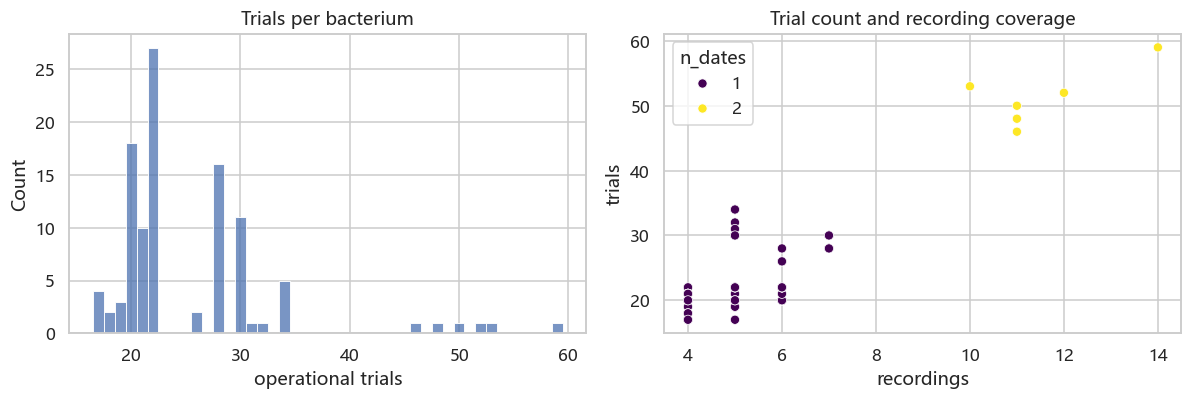

In [22]:
sample_recordings = trials[[*recording_key, "sample_id"]].drop_duplicates()
per_sample = trials.groupby("sample_id").agg(
    n_trials=("segment_index", "size"),
    n_dates=("date", "nunique"),
    dates=("date", lambda x: ", ".join(sorted(x.unique()))),
)
per_sample["n_recordings"] = sample_recordings.groupby("sample_id").size()
per_sample = per_sample[["n_trials", "n_recordings", "n_dates", "dates"]]

display(per_sample[["n_trials", "n_recordings", "n_dates"]].describe().round(2))
display(pd.concat({"lowest trial count": per_sample.nsmallest(10, "n_trials"),
                   "highest trial count": per_sample.nlargest(10, "n_trials")}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(per_sample["n_trials"], discrete=True, ax=axes[0])
axes[0].set(title="Trials per bacterium", xlabel="operational trials")
sns.scatterplot(data=per_sample, x="n_recordings", y="n_trials", hue="n_dates", palette="viridis", ax=axes[1])
axes[1].set(title="Trial count and recording coverage", xlabel="recordings", ylabel="trials")
plt.tight_layout()
plt.show()

### Observation

每个细菌有 17–59 个 trials（中位数 22），覆盖 4–14 个 recordings。106 个中有 100 个只在一个日期出现；跨日期样本因为增加了 recording，通常也有更多 trials。后续任何 bacteria-level 比较都不能把 2,696 个 trials 当成完全独立重复。

### Question

每天测了哪些细菌？哪些细菌跨日期重复？

,n_trials,n_samples,n_worm_recordings,sample_ids
date,,,,
20260311,253,13,4,"A226, A228, A231, A232, A234, A235, A236, A237, A238, A240, A241, A246, A248"
20260313,265,13,4,"A095, A132, A137, A139, A148, A151, A165, A178, A179, A181, A189, A247, A249"
20260331,413,13,5,"A025, A026, A065, A074, A075, A079, A080, A084, A085, A093, A138, A206, A215"
20260410,285,13,6,"A077, A136, A146, A184, A187, A257, A260, A287, A289, A290, A292, A293, A297"
20260414,270,13,5,"A013, A014, A024, A025, A029, A034, A044, A073, A200, A253, A285, A294, A305"
20260429,370,13,7,"A011, A038, A040, A041, A044, A045, A048, A049, A255, A258, A264, A266, A268"
20260520,319,11,7,"A001, A002, A005, A006, A007, A008, A010, A011, A291, A296, A300"
20260601,282,12,6,"A009, A013, A014, A015, A016, A017, A019, A020, A021, A022, A023, A024"
20260609,239,11,5,"A110, A113, A118, A128, A199, A269, A288, A295, A298, A299, A302"


,n_trials,n_recordings,n_dates,dates
sample_id,,,,
A011,59,14,2,"20260429, 20260520"
A013,50,11,2,"20260414, 20260601"
A014,46,11,2,"20260414, 20260601"
A024,48,11,2,"20260414, 20260601"
A025,53,10,2,"20260331, 20260414"
A044,52,12,2,"20260414, 20260429"


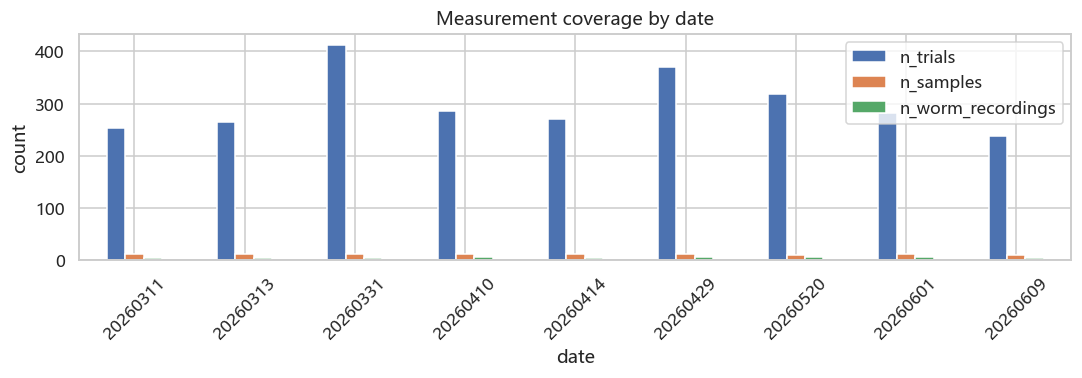

In [23]:
date_summary = trials.groupby("date").agg(
    n_trials=("segment_index", "size"),
    n_samples=("sample_id", "nunique"),
    n_worm_recordings=("worm_key", "nunique"),
)
samples_per_date = trials.groupby("date")["sample_id"].agg(
    lambda x: ", ".join(sorted(x.unique()))
)
date_table = date_summary.join(samples_per_date.rename("sample_ids"))

cross_date = per_sample.loc[per_sample["n_dates"] > 1].sort_index()
display(date_table)
display(cross_date)

fig, ax = plt.subplots(figsize=(10, 3.6))
date_summary[["n_trials", "n_samples", "n_worm_recordings"]].plot.bar(ax=ax)
ax.set(title="Measurement coverage by date", xlabel="date", ylabel="count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Observation

数据覆盖 9 个日期。每天有 11–13 个细菌、4–7 个 `(date, worm)` recordings 和 239–413 个 trials。跨日期重复仅有 6 个样本：A011、A013、A014、A024、A025、A044；每个都出现在两个日期。日期与细菌集合高度绑定，因此 date/batch 与 bacteria identity 存在明显混杂，后续必须保留日期层级。

### Question

每个 trial 有哪些 neuron？neuron panel 在同一 recording 内是否稳定？

,neurons_per_trial
count,2696.00
mean,18.06
std,3.25
min,8.00
25%,16.00
50%,19.00
75%,20.00
max,25.00


,n_trials
neuron,
8,74
10,39
12,42
13,52
14,205
15,66
16,230
17,161
18,297


unique neuron-set count within each recording:


,n_recordings
neuron,
1,49


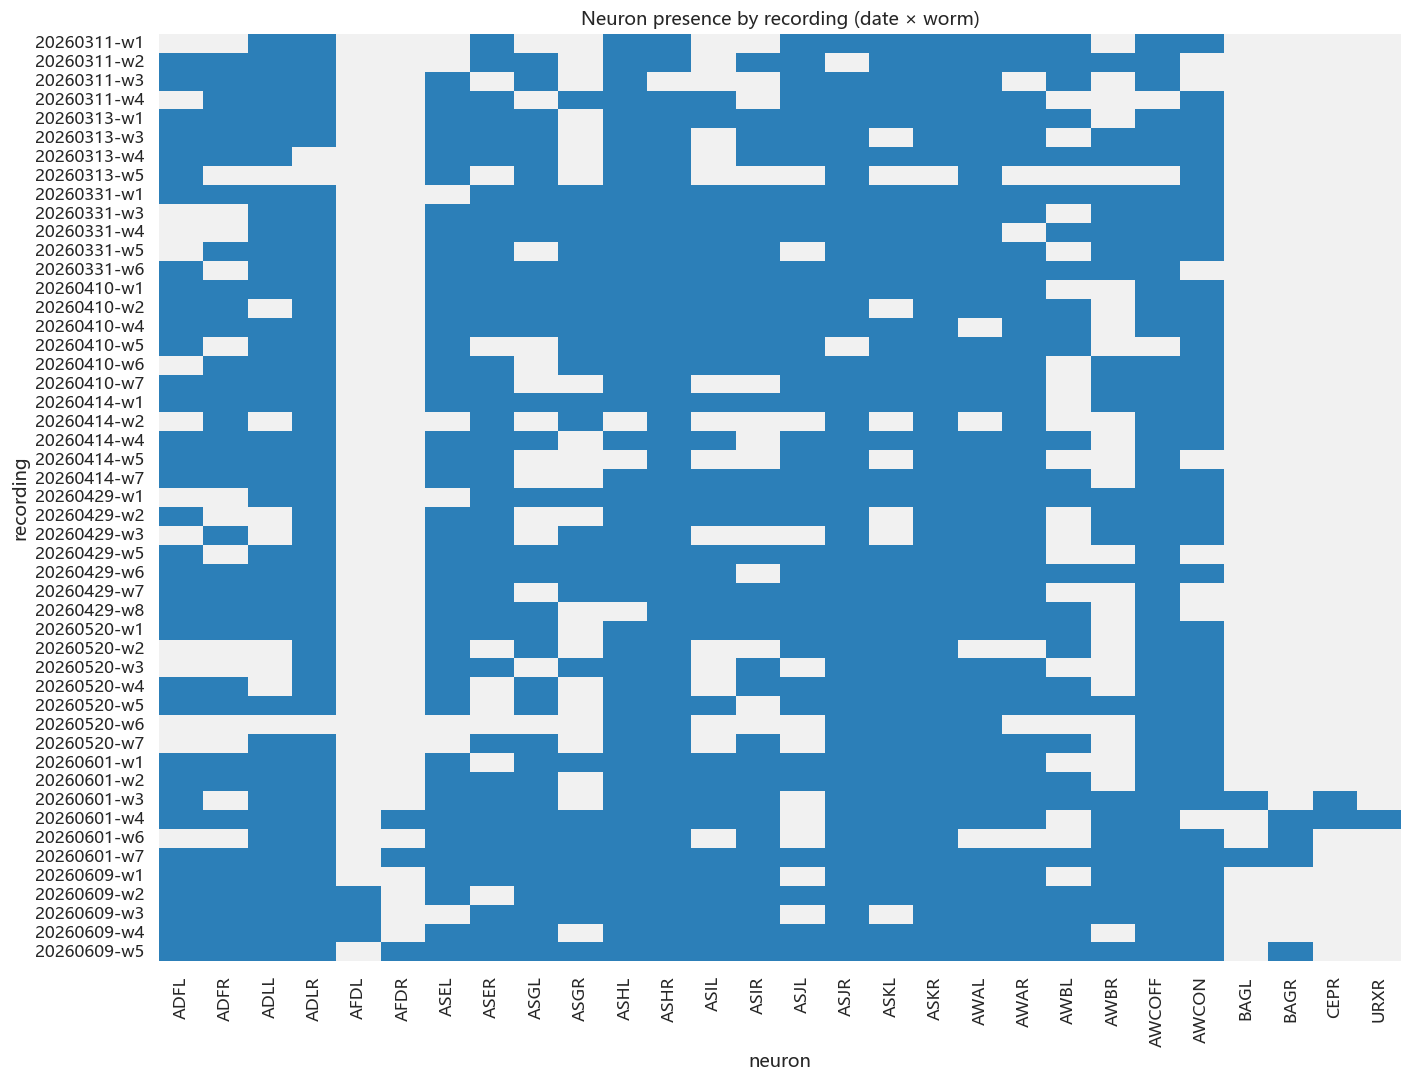

In [24]:
trial_neuron_sets = traces.groupby(trial_key)["neuron"].agg(lambda x: tuple(sorted(x)))
trial_neuron_n = trial_neuron_sets.str.len()
recording_neuron_sets = traces.groupby(recording_key)["neuron"].agg(lambda x: tuple(sorted(x.unique())))
sets_per_recording = trial_neuron_sets.groupby(level=recording_key).nunique()

display(trial_neuron_n.describe().round(2).to_frame("neurons_per_trial"))
display(trial_neuron_n.value_counts().sort_index().rename("n_trials").to_frame())
print("unique neuron-set count within each recording:")
display(sets_per_recording.value_counts().sort_index().rename("n_recordings").to_frame())

recording_presence = (
    traces[[*recording_key, "neuron"]]
    .drop_duplicates()
    .assign(present=1)
    .pivot_table(index=recording_key, columns="neuron", values="present", fill_value=0)
)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(recording_presence, cmap=["#f1f1f1", "#2c7fb8"], cbar=False, ax=ax)
ax.set_title("Neuron presence by recording (date × worm)")
ax.set_xlabel("neuron")
ax.set_ylabel("recording")
plt.tight_layout()
plt.show()

### Observation

每个 trial 有 8–25 个 neurons（中位数 19）。49 个 recordings 中，每一个 recording 内的 neuron set 都完全不变；trial 之间 neuron 数差异来自 recording-level panel 不同，而不是同一 recording 中某些 trial 随机掉 neuron。全局 28-neuron union 不应被当作每个 trial 的预期 panel。

### Question

数值缺失、timepoint 缺失和 neuron 缺失分别是多少？

In [25]:
recording_union = traces.groupby(recording_key)["neuron"].agg(set)
recording_trial_n = trials.groupby(recording_key).size()
expected_trace_slots = sum(
    len(recording_union.loc[key]) * int(recording_trial_n.loc[key])
    for key in recording_union.index
)

missing_summary = pd.Series(
    {
        "NaN rate among stored ΔF/F0 values": df["delta_F_over_F0"].isna().mean(),
        "non-finite rate among stored ΔF/F0 values": (~np.isfinite(df["delta_F_over_F0"].to_numpy())).mean(),
        "incomplete trace rate (expected timepoints 0–44)": (trace_time["nunique"] != 45).mean(),
        "duplicate row rate under full key": df.duplicated(row_key).mean(),
        "missing neuron-trace rate within recording-specific panels": 1 - len(traces) / expected_trace_slots,
    },
    name="rate",
)
display(missing_summary.map(lambda x: f"{x:.3%}").to_frame())

neuron_coverage = traces.groupby("neuron").agg(
    n_traces=("segment_index", "size"),
    n_recordings=("date", "size"),
)
neuron_coverage["n_recordings"] = (
    traces[[*recording_key, "neuron"]].drop_duplicates().groupby("neuron").size()
)
neuron_coverage["fraction_of_all_trials"] = neuron_coverage["n_traces"] / len(trials)
display(neuron_coverage.sort_values("fraction_of_all_trials").round(3))

,rate
NaN rate among stored ΔF/F0 values,0.000%
non-finite rate among stored ΔF/F0 values,0.000%
incomplete trace rate (expected timepoints 0–44),0.000%
duplicate row rate under full key,0.000%
missing neuron-trace rate within recording-specific panels,0.000%


,n_traces,n_recordings,fraction_of_all_trials
neuron,,,
URXR,54,1,0.020
BAGL,96,2,0.036
CEPR,102,2,0.038
AFDR,146,3,0.054
AFDL,154,3,0.057
BAGR,194,4,0.072
AWBR,1412,24,0.524
ASGR,1505,27,0.558
AWBL,1587,28,0.589


### Observation

在正确 key 和 recording-specific neuron panel 下，五项 missing/duplicate 指标都是 0%。但这不表示每个 neuron 覆盖所有 recordings：例如少见的 BAGL/BAGR/CEPR/URXR 只出现在少数 recording panel。应把这种差异称为 **coverage**，而不是把未成像/未标注的 neuron 自动填成 0 或 NaN。

### Question

`start_time` / `end_time` 对应哪些 timepoints？当前文件能否确认秒数和端点包含规则？

In [26]:
time_contract = pd.Series(
    {
        "time_point_min": df["time_point"].min(),
        "time_point_max": df["time_point"].max(),
        "n_time_points": df["time_point"].nunique(),
        "unique_start_time": df["start_time"].nunique(),
        "start_time_value": df["start_time"].iloc[0],
        "unique_end_time": df["end_time"].nunique(),
        "end_time_value": df["end_time"].iloc[0],
        "sampling_interval_column_present": any(
            name in df.columns for name in ["sampling_interval", "dt", "time_seconds"]
        ),
    },
    name="value",
)
display(time_contract.to_frame())

ONSET = int(df["start_time"].iloc[0])
OFFSET = int(df["end_time"].iloc[0])

# 工作假设：end_time 是 exclusive boundary。修改这一行即可测试另一种约定。
END_IS_EXCLUSIVE = True
phase_table = pd.DataFrame(
    {
        "phase": ["baseline", "stimulus (working assumption)", "post-stimulus"],
        "timepoints": [
            list(range(0, ONSET)),
            list(range(ONSET, OFFSET if END_IS_EXCLUSIVE else OFFSET + 1)),
            list(range(OFFSET if END_IS_EXCLUSIVE else OFFSET + 1, 45)),
        ],
    }
)
phase_table["n_points"] = phase_table["timepoints"].str.len()
display(phase_table)

,value
time_point_min,0
time_point_max,44
n_time_points,45
unique_start_time,1
start_time_value,5
unique_end_time,1
end_time_value,15
sampling_interval_column_present,False


,phase,timepoints,n_points
0,baseline,"[0, 1, 2, 3, 4]",5
1,stimulus (working assumption),"[5, 6, 7, 8, 9, 10, 11, 12, 13, 14]",10
2,post-stimulus,"[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,...",30


### Observation

所有行的 onset marker 都是 5，offset marker 都是 15。表本身没有采样间隔或绝对秒数列，因此只能确认索引，不能独立证明 1 point = 1 s。当前工作约定把 `end_time` 视为 exclusive boundary：baseline 0–4（5 点）、stimulus 5–14（10 点）、post 15–44（30 点）。若 protocol 把 15 也算刺激期，只需切换 `END_IS_EXCLUSIVE`；在 protocol 确认前不要把这项约定写成事实。

### Question

能否从已归一化的 traces 反推当前 baseline 使用了哪些点？

In [27]:
baseline_rows = df[df["time_point"] < ONSET]
baseline_trace = baseline_rows.groupby(trace_key)["delta_F_over_F0"].agg(
    baseline_mean="mean",
    baseline_sd="std",
    baseline_range=lambda x: x.max() - x.min(),
)

display(
    baseline_trace[["baseline_mean", "baseline_sd", "baseline_range"]]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .round(5)
)
print("max |mean ΔF/F0 over timepoints 0–4|:", baseline_trace["baseline_mean"].abs().max())

,baseline_mean,baseline_sd,baseline_range
count,48701.0,48701.00000,48701.00000
mean,-0.0,0.06853,0.16916
std,0.0,0.05613,0.13879
min,-0.0,0.00025,0.00066
50%,0.0,0.05386,0.13239
90%,0.0,0.13009,0.32118
95%,0.0,0.16700,0.41388
99%,0.0,0.27326,0.67387
max,0.0,1.69314,3.54074


max |mean ΔF/F0 over timepoints 0–4|: 3.552713678800501e-16


### Observation

48,701 条 trace 在 timepoints 0–4 上的平均 $\Delta F/F_0$ 都等于 0（最大浮点误差约 $3.6	imes10^{-16}$）。这强烈支持 0–4 是归一化所用 baseline window，并且归一化使该窗口均值归零。仅凭归一化结果仍不能证明上游 $F_0$ 的精确公式、去漂白步骤或是否有其他预处理；这些需要 raw fluorescence 或生成记录。

### Question

每个 trial 的 baseline fluctuation 多大，是否集中在某些日期或 recordings？

,n_neurons,median_neuron_sd,p90_neuron_sd,max_neuron_sd
count,2696.0000,2696.0000,2696.0000,2696.0000
mean,18.0642,0.0566,0.1165,0.1876
std,3.2517,0.0213,0.0448,0.1105
min,8.0000,0.0192,0.0404,0.0440
50%,19.0000,0.0523,0.1075,0.1609
90%,21.0000,0.0823,0.1727,0.2995
95%,23.0000,0.0960,0.2025,0.3700
99%,25.0000,0.1212,0.2674,0.6252
max,25.0000,0.2571,0.4331,1.6931


n_neurons  median_neuron_sd  \
date     worm_key sample_id segment_index                                
20260331 w4       A074      78                    19            0.2571   
                  A084      94                    19            0.2338   
                  A025      83                    19            0.2015   
                  A080      93                    19            0.1951   
                  A079      88                    19            0.1913   
                  A075      85                    19            0.1838   
20260410 w4       A136      22                    20            0.1789   
         w2       A290      61                    19            0.1751   
20260331 w3       A075      56                    19            0.1693   
         w4       A084      31                    19            0.1596   
                  A138      81                    19            0.1482   
20260601 w7       A022      54                    25            0.1435   

                                           p90_neuron_sd  max_neuron_sd  
date     worm_key sample_id segment_index                                
20260331 w4       A074      78                    0.4296         0.7911  
                  A084      94                    0.4011         0.5589  
                  A025      83                    0.4331         0.5569  
                  A080      93                    0.3502         0.5216  
                  A079      88                    0.3580         0.4130  
                  A075      85                    0.3467         0.4447  
20260410 w4       A136      22                    0.2645         0.3450  
         w2       A290      61                    0.2116         0.2630  
20260331 w3       A075      56                    0.2726         0.2927  
         w4       A084      31                    0.2620         0.2756  
                  A138      81                    0.2998         0.5190  
20260601 w7       A022      54                    0.2132         0.8543

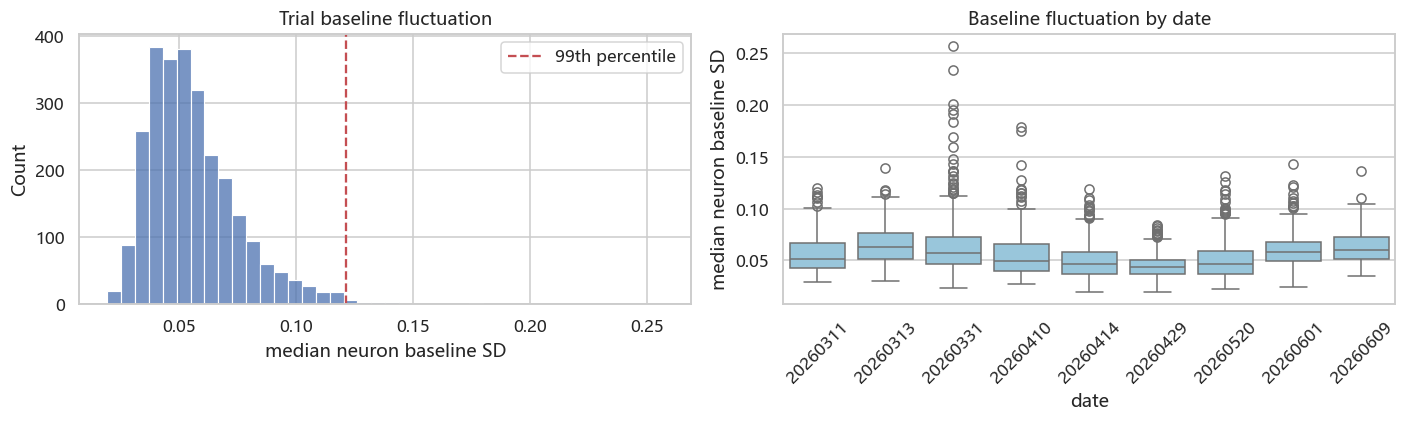

In [28]:
trial_baseline = baseline_trace.groupby(level=trial_key).agg(
    n_neurons=("baseline_sd", "size"),
    median_neuron_sd=("baseline_sd", "median"),
    p90_neuron_sd=("baseline_sd", lambda x: x.quantile(0.9)),
    max_neuron_sd=("baseline_sd", "max"),
)

display(
    trial_baseline.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(4)
)
display(trial_baseline.nlargest(12, "median_neuron_sd").round(4))

plot_baseline = trial_baseline.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(plot_baseline["median_neuron_sd"], bins=40, ax=axes[0])
axes[0].axvline(plot_baseline["median_neuron_sd"].quantile(0.99), color="C3", ls="--", label="99th percentile")
axes[0].legend()
axes[0].set(title="Trial baseline fluctuation", xlabel="median neuron baseline SD")
sns.boxplot(data=plot_baseline, x="date", y="median_neuron_sd", color="#8ecae6", ax=axes[1])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set(title="Baseline fluctuation by date", xlabel="date", ylabel="median neuron baseline SD")
plt.tight_layout()
plt.show()

### Observation

trial-level median neuron baseline SD 的中位数为 0.0523，95th percentile 为 0.0960，99th percentile 为 0.1212，最大值 0.2571。最高的 6 个 trial 全来自 2026-03-31 的 w4，说明至少存在 recording-level 状态或质量差异。每条 baseline 只有 5 个点，SD 估计本身很不稳定；这里把它当作排序和看原始曲线的诊断量，不设自动剔除阈值。

### Question

baseline SD 最大的 traces 是单点跳变，还是持续波动？

,date,worm_key,sample_id,segment_index,neuron,baseline_mean,baseline_sd,baseline_range
0,20260414,w2,A013,19,ASJR,0.0,1.6931,3.5407
1,20260520,w1,A011,78,ASJL,-0.0,1.3277,3.5101
2,20260601,w7,A009,44,ASIL,-0.0,1.2315,3.2481
3,20260601,w7,A023,50,ASIL,0.0,1.1535,2.8817
4,20260601,w7,A017,28,ASIL,0.0,1.0163,2.5032
5,20260609,w5,A269,50,ASEL,-0.0,0.9033,2.4120
6,20260601,w7,A022,54,ASIL,0.0,0.8543,2.2418
7,20260609,w5,A295,20,ASEL,-0.0,0.8017,1.8555


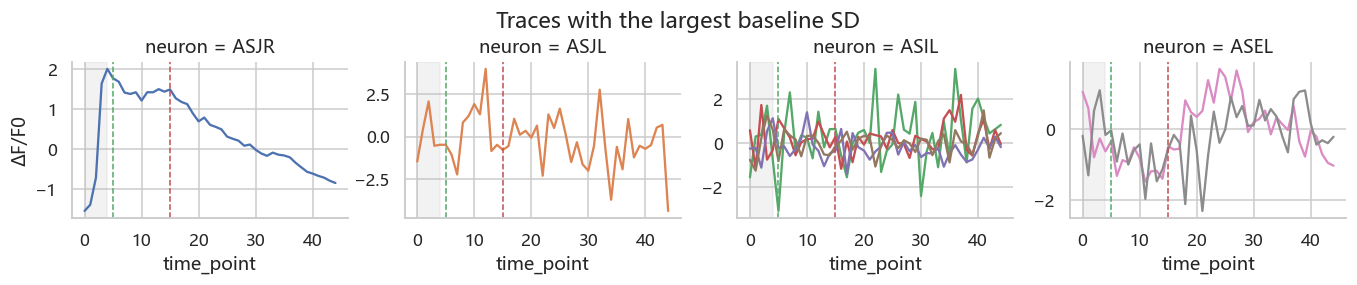

In [29]:
worst_baseline = baseline_trace.nlargest(8, "baseline_sd").reset_index()
display(worst_baseline.round(4))

worst_baseline_curves = df.merge(worst_baseline[trace_key], on=trace_key, how="inner")
g = sns.FacetGrid(
    worst_baseline_curves,
    col="neuron",
    col_wrap=4,
    hue="sample_id",
    sharey=False,
    height=2.5,
    aspect=1.25,
)
g.map_dataframe(sns.lineplot, x="time_point", y="delta_F_over_F0", estimator=None)
for ax in g.axes.flat:
    ax.axvspan(0, ONSET - 1, color="#bbbbbb", alpha=0.18)
    ax.axvline(ONSET, color="C2", ls="--", lw=1)
    ax.axvline(OFFSET, color="C3", ls="--", lw=1)
g.set_axis_labels("time_point", "ΔF/F0")
g.fig.suptitle("Traces with the largest baseline SD", y=1.03)
plt.show()

### Observation

最大的单条 baseline SD 为 1.693（2026-04-14, w2, A013, segment 19, ASJR）。高 baseline SD 涉及 ASJR、ASJL、ASIL、ASEL、AWCON 等不同 neurons 和多个 recordings；原始曲线可用于区分宽幅波动、漂移和个别点跳变。现阶段只标记、追溯，不删除。

### Question

是否存在极端 $\Delta F/F_0$ traces，它们集中在哪些 neurons？

,max_abs
0.500,0.3750
0.900,0.9426
0.950,1.3032
0.990,2.4794
0.999,7.5480
1.000,10.0280


,|ΔF/F0| threshold,n_traces,AWCON_traces
0,2,872,209
1,3,293,156
2,5,118,94
3,8,35,33


,date,worm_key,sample_id,segment_index,neuron,trace_min,trace_max,trace_mean,trace_sd,max_abs,baseline_mean,baseline_sd,baseline_range
0,20260410,w6,A289,40,AWCON,-0.0970,10.0280,3.1905,3.6550,10.0280,-0.0,0.1067,0.2761
1,20260520,w1,A296,70,AWCON,-0.0920,9.9997,2.8561,3.4760,9.9997,0.0,0.0851,0.1975
2,20260410,w6,A289,9,AWCON,-0.0699,9.9338,2.7492,3.4542,9.9338,0.0,0.0212,0.0551
3,20260609,w1,A302,10,AWCON,-0.3292,9.8674,2.1829,3.3902,9.8674,-0.0,0.1652,0.3879
4,20260609,w1,A288,24,AWCON,-0.4441,9.8564,2.2950,3.4149,9.8564,0.0,0.3350,0.9178
5,20260410,w6,A289,8,AWCON,-0.2474,9.8548,3.1392,3.5842,9.8548,-0.0,0.0651,0.1706
6,20260520,w1,A296,58,AWCON,-0.0883,9.8090,3.4425,3.6834,9.8090,0.0,0.0545,0.1482
7,20260520,w1,A296,14,AWCON,-0.0487,9.7475,3.4624,3.5001,9.7475,-0.0,0.0512,0.1158
8,20260410,w6,A290,28,AWCON,-0.2402,9.7469,3.1677,3.7477,9.7469,0.0,0.0949,0.2319
9,20260520,w3,A296,14,AWCON,-0.3184,9.5933,2.9909,3.6324,9.5933,-0.0,0.1495,0.3900


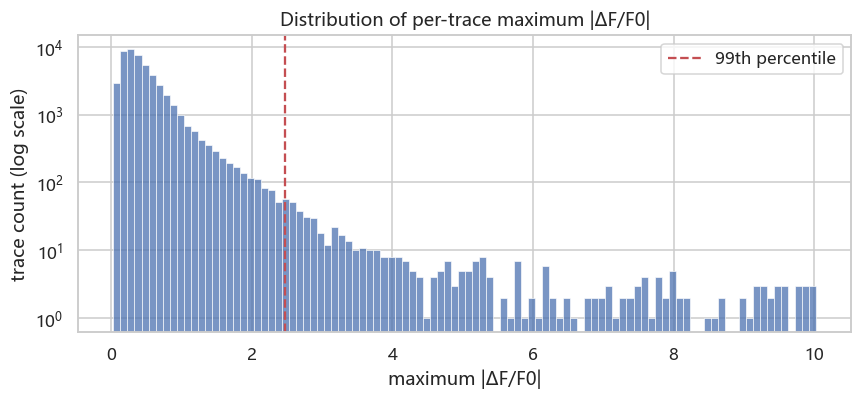

In [30]:
trace_stats = df.groupby(trace_key)["delta_F_over_F0"].agg(
    trace_min="min",
    trace_max="max",
    trace_mean="mean",
    trace_sd="std",
)
trace_stats["max_abs"] = trace_stats[["trace_min", "trace_max"]].abs().max(axis=1)
trace_stats = trace_stats.join(baseline_trace)

quantiles = trace_stats["max_abs"].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0])
threshold_counts = []
for threshold in [2, 3, 5, 8]:
    selected = trace_stats[trace_stats["max_abs"] >= threshold].reset_index()
    threshold_counts.append(
        {
            "|ΔF/F0| threshold": threshold,
            "n_traces": len(selected),
            "AWCON_traces": int((selected["neuron"] == "AWCON").sum()),
        }
    )

top_extreme = trace_stats.nlargest(15, "max_abs").reset_index()
display(quantiles.rename("max_abs").to_frame().round(4))
display(pd.DataFrame(threshold_counts))
display(top_extreme.round(4))

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.histplot(trace_stats["max_abs"], bins=100, ax=ax)
ax.set_yscale("log")
ax.axvline(quantiles.loc[0.99], color="C3", ls="--", label="99th percentile")
ax.set(title="Distribution of per-trace maximum |ΔF/F0|", xlabel="maximum |ΔF/F0|", ylabel="trace count (log scale)")
ax.legend()
plt.tight_layout()
plt.show()

### Observation

per-trace 最大绝对幅度的 99th percentile 为 2.479，99.9th percentile 为 7.548，最大值为 10.028。共有 118 条 trace 达到 $|\Delta F/F_0|\ge5$，其中 94 条是 AWCON；达到 8 的 35 条中 33 条是 AWCON。极值明显有 neuron 结构，不能用单一全局阈值自动当作坏数据。

### Question

幅度最大的 traces 看起来像孤立坏点，还是完整的刺激相关动态？

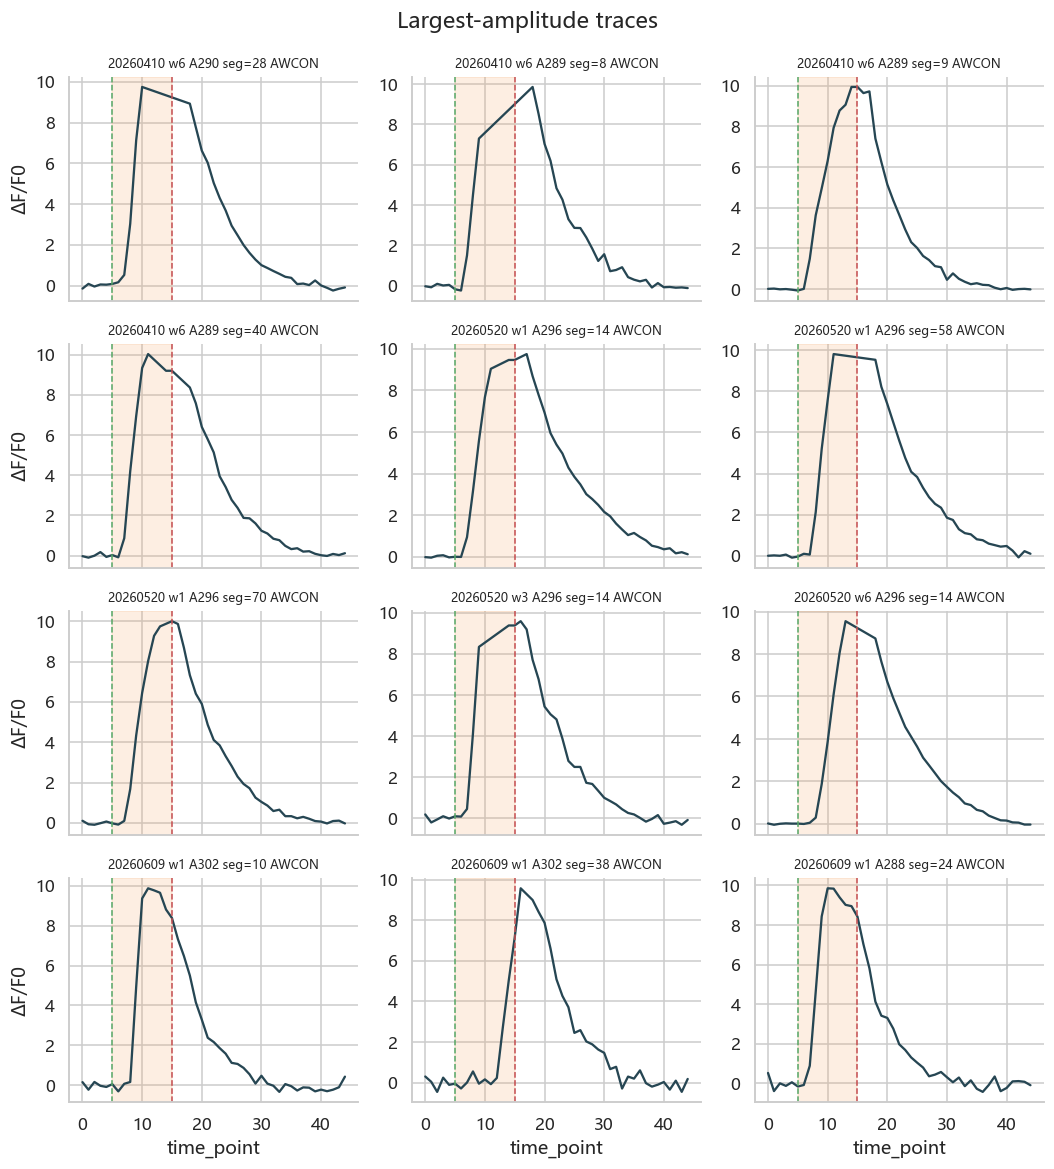

In [31]:
top_plot_keys = top_extreme.head(12)[trace_key]
top_curves = df.merge(top_plot_keys, on=trace_key, how="inner")
top_curves["trace_label"] = (
    top_curves["date"].astype(str) + " "
    + top_curves["worm_key"] + " "
    + top_curves["sample_id"] + " seg="
    + top_curves["segment_index"].astype(str) + " "
    + top_curves["neuron"]
)

g = sns.FacetGrid(
    top_curves,
    col="trace_label",
    col_wrap=3,
    sharey=False,
    height=2.6,
    aspect=1.25,
)
g.map_dataframe(sns.lineplot, x="time_point", y="delta_F_over_F0", estimator=None, color="#264653")
for ax in g.axes.flat:
    ax.axvspan(ONSET, OFFSET, color="#f4a261", alpha=0.18)
    ax.axvline(ONSET, color="C2", ls="--", lw=1)
    ax.axvline(OFFSET, color="C3", ls="--", lw=1)
g.set_titles("{col_name}", size=8)
g.set_axis_labels("time_point", "ΔF/F0")
g.fig.suptitle("Largest-amplitude traces", y=1.02)
plt.show()

### Observation

最高幅 trace（2026-04-10, w6, A289, segment 40, AWCON）从 onset 后连续上升，在 timepoint 11 达到 10.028，随后缓慢衰减到记录末端；它不是一个孤立数值坏点。多个高幅 AWCON traces 也呈连续动力学。它们可能是真实强响应，也可能受很小 $F_0$、饱和或上游处理影响；需要 raw fluorescence、曝光/增益和 $F_0$ 记录才能判定。当前只建立 review list，不剔除。

## 本轮 measurement checkpoint

已经可以直接从文件确认：

- 106 个神经刺激样本，49 个 date × worm recordings，2,696 个 operational trials，48,701 条完整 45-point traces。
- `(date, worm_key)` 是最低限度的 recording key；忽略 date 会制造伪重复。
- neuron panel 在每个 recording 内恒定，跨 recording 不同。
- 存储值、timepoints、正确复合键和 recording-specific neuron slots 均无 missing/duplicate。
- onset/offset markers 为 5/15；0–4 的 baseline 均值对每条 trace 精确归零。
- baseline fluctuation 存在 recording-level 集中；极端幅度主要集中在 AWCON，并呈完整连续动态。

## 进入下一轮前需要确认的 protocol 问题

1. 每个 `time_point` 是否严格等于 1 s？一个 point 是一帧还是一个完整 volume？
2. `end_time=15` 是 exclusive boundary 还是刺激仍覆盖 timepoint 15？
3. `(date, worm_key)` 是否一一对应独立动物？是否存在同一动物跨日/跨 recording？
4. `segment_index` 的来源是什么？它是否严格等于一次 stimulus presentation/trial？
5. $\Delta F/F_0$ 的 $F_0$ 精确公式、motion correction、photobleaching correction 和去噪步骤是什么？
6. 是否保存 raw fluorescence、stimulus TTL/同步日志、volume timing、voxel size 和 z-step？
7. 原始 LCMS 中 20 个 raw-only samples 为什么未进入 299-sample fold-change matrix？

这些问题确认前，不继续做跨菌株表征、相似性或 feature screen。